## Distributed Acoustic Sensing (DAS) 
### Fiber optics for Oceanographic Applications <img src="HCMR_logo.jpg" width="200" align="right" style="margin-right: 20px;">


**Presenters:** [Aggeliki Barberopoulou](https://io.hcmr.gr/member-page-2/?memberid=barberopouloua), [Thania Papapostolou](https://io.hcmr.gr/member-page-2/?memberid=papapostoloua) (Hellenic Center for Marine Research) <br>

**Objectives:**
* Read one DAS file
* Visualise data in time and frequency domains
* Present some examples of processing data for analysis


<br>

***

In this notebook we will take a look at a basic methodology one can follow to read 
 <img src="GeoLab_Madeira_Credits_Loureiro_ARDITI.png" width="300" align="right" style="margin-right: 20px;"> 
and visualise DAS files. 

For our demonstration we are using a 1 hour DAS file constructed
from data recorded by the GeoLab fibre, installed on the southern coast of Madeira Island, Portugal.  &nbsp;

The data file was originally prepapred as follows:
* concatenated from 10 second DAS data (500Hz sampling rate) into 1 hour files, 
* filtered with a 4th order butterworth filter (cutoff frequency = 45Hz),
* downsampled to 50Hz
* Number of channels were also reduced to about 1/10th (1137)

The above processing has been semi automated and this is a sample of the work performed &nbsp;
on records to identify "critical" energy &nbsp;

To facilitate the training session the 50Hz file was further downsampled to 2Hz


**Acknowledgments:** GeoLab is an initiative aimed at the research community with the participation of Fundação para a Ciência e Tec30
nologia (FCT), Fundação para a Computação Científica Nacional (FCCN), Agência Regional para o Desenvolvimento (Credits: Loureiro et al. 2026)
  


<center> Created by Aggeliki Barberopoulou on March 19, 2026</center>


1. Importing of necessary modules for processing
***

In [1]:
import sys
print(sys.version)

3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]


In [3]:
# Import only needed modules
# for signal processing and
# numerical and mathematical operations
import numpy as np
import os # for path manipulation
import h5py # for hdf5 file handling

# for plotting and visualisation
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.colors as colors
from matplotlib.ticker import MaxNLocator
from IPython.display import clear_output #clearing space

from scipy import signal
import scipy.signal as signal
from scipy.signal.windows import tukey
from scipy.fft import fft, fftfreq
import scipy.fft as ft
import scipy
from scipy.signal import welch, butter, filtfilt

Checking working directory for reading files
***

In [5]:
cwd = os.getcwd()
file1 = 'DAS_onehr_2hz.h5' # file we will read
full_path = os.path.join(cwd,'data', file1)
print(file1)

DAS_onehr_2hz.h5


Reading concatenated file with DAS data
***

In [6]:
# concat_df = pd.read_hdf(full_path,key='data') # read the concatenated pandas dataframe file (1 hour worth of record)
with h5py.File(full_path, "r") as f:
    # Print all root level object names (aka keys) 
    # these can be group or dataset names 
    print("Keys: %s" % f.keys())
    dset = f['data'][:].astype('float32') # save as numpy array
    print(dset.dtype,dset.shape)   

Keys: <KeysViewHDF5 ['data', 'distances']>
float32 (7200, 1127)


__1. Plotting a single timeseries:__
What does a single timeseries record look like?

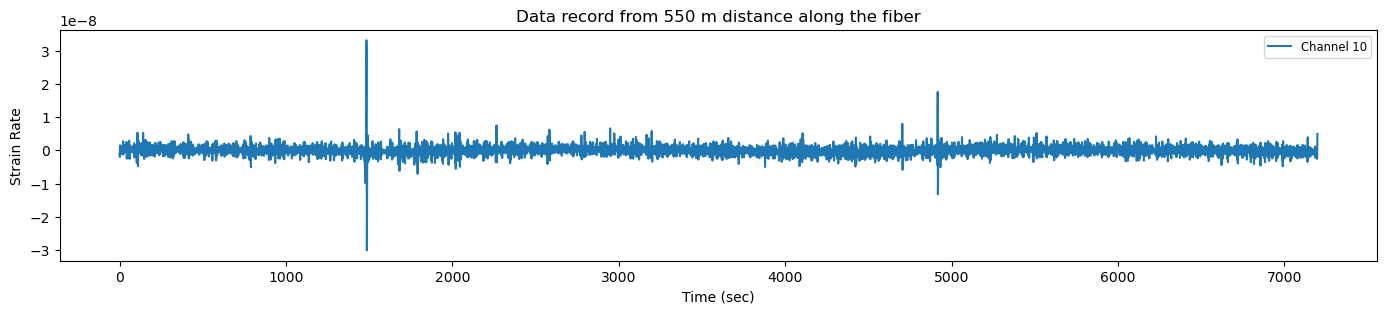

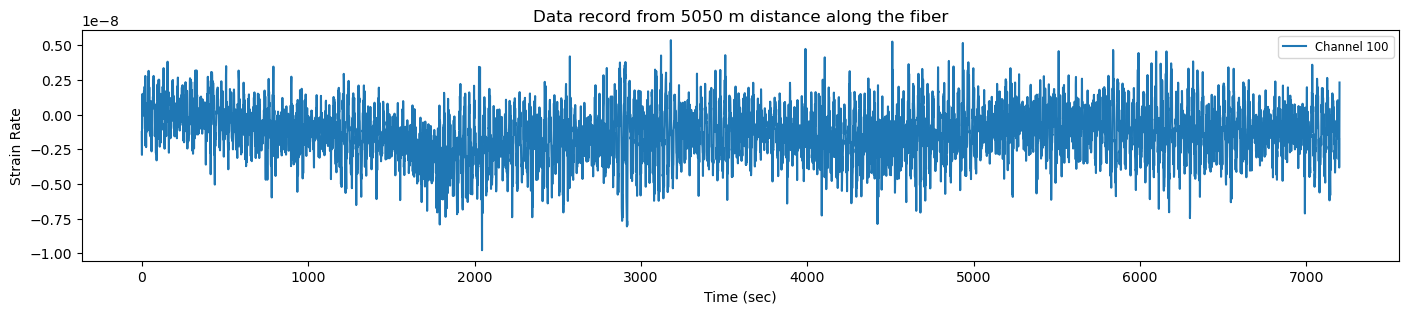

In [7]:
# Function which plots a single timeseries out of a pandas dataframe
def single_timeseries(ChannelNo):
    '''Functions plots a single time series from 
    a pandas dataframe
    Takes 1 input a channel number
    '''
    offset = 50 # removed first 10 channels from original file
    distance_along_fiber = offset + ChannelNo*50
    fig = plt.figure(2,figsize=(17,3),clear=True);
    plt.plot(dset[:,ChannelNo],label=f'Channel {ChannelNo}')
    # Create the legend once, after all plots are added
    # Matplotlib will automatically collect all 'label' arguments from the plt.plot calls
    plt.legend(loc='best', fontsize='small', ncol=2) # 'best' tries to find an optimal spot, ncol can help with many labels
    plt.title(f'Data record from {distance_along_fiber} m distance along the fiber' )
    plt.xlabel('Time (sec)')
    plt.ylabel('Strain Rate')
    ## plt.savefig(f'raw_concat_1hour_channel{a}{mytext}.png')
    ## plt.close(fig) # to save memory
    plt.show()
single_timeseries(10)
single_timeseries(100)

__2. What about the spectrograms and spectra of these series?__

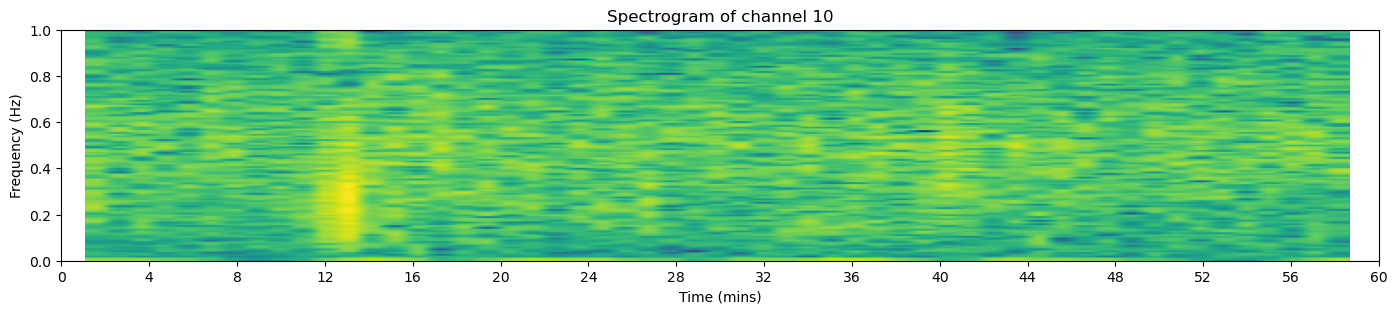

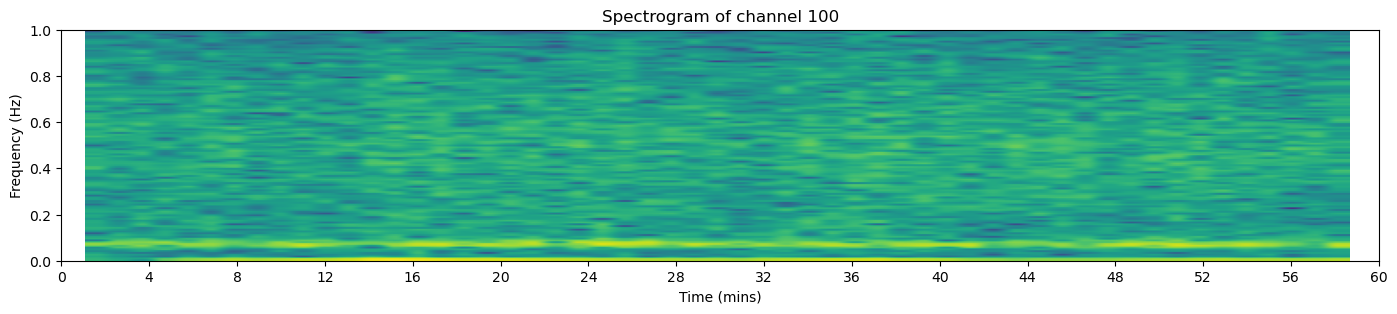

In [14]:
def plot_spectrogram(channel_data,a,Fs,mytitle):
    channel_data = channel_data[:,a] #.squeeze() # squeeze is needed as specgram expects a series
    fs = Fs # sampling frequency


    # Matplotlib.pyplot.specgram() function to
    # generate spectrogram
    fig = plt.figure(2,figsize=(17,3),clear=True)
    # powerSpectrum, frequenciesFound, time, imageAxis = plt.specgram(x550, fs)
    Pxx, freqs, time, imageAxis = plt.specgram(channel_data,  Fs=fs)

    # time.max() returns the end time of the signal in seconds (~3610 seconds)
    max_time_mins = time.max() / 60
    ## print(max_time_mins)

    # 2. Set the x-axis limits to match the range of the 'time' array
    # imageAxis is the AxesImage object. We use .set_extent() on it.
    # The extent is (xmin, xmax, ymin, ymax).
    # xmin is 0, xmax is the last value in the 'time' array.
    # ymin is 0, ymax is fs/2 (the Nyquist frequency).
    imageAxis.set_extent([time.min(), time.max(), 0, fs / 2])
    # CRITICAL: Limit the visible X-axis to the exact end of your data (in seconds)
    plt.xlim(time.min(), time.max())

    # 3. Define and Apply Explicit X-axis Tick Labels (in minutes)

    # Find 'nice' tick locations based on the range in MINUTES (0 to ~60 min)
    locator = MaxNLocator(nbins=15) 
    tick_locations_mins = locator.tick_values(0, max_time_mins)

    # Convert the "nice" tick values back into SECONDS for plotting locations
    tick_locations_sec = tick_locations_mins * 60

    # Format the tick values (in minutes) into clean labels
    time_labels_mins = [f'{t:.0f}' for t in tick_locations_mins] # Use no decimals for clean minutes

    # Apply the labels: Use SECONDS for the locations, but MINUTES for the labels
    plt.xticks(tick_locations_sec, time_labels_mins)

    plt.title(f'Spectrogram of channel {a}'+ mytitle)
    plt.xlabel('Time (mins)')
    plt.ylabel('Frequency (Hz)')
    ## plt.savefig(f'Spectrogram Channel {a} {mytitle}')
    ## plt.close(fig)
    plt.show()
plot_spectrogram(dset,10,2,'')
plot_spectrogram(dset,100,2,'')

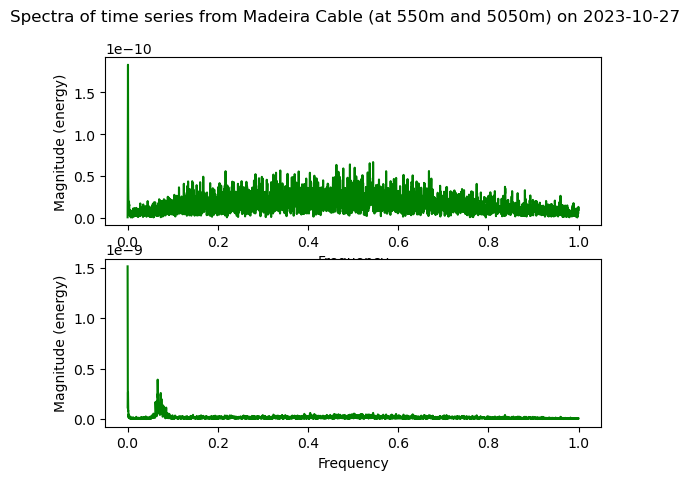

In [15]:
fig, axs = plt.subplots(2)
fig.suptitle('Spectra of time series from Madeira Cable (at 550m and 5050m) on 2023-10-27')
# plotting the magnitude spectrum of the signal 
## axs[0].magnitude_spectrum(dset[:,10], color ='green',scale='dB')
## axs[1].magnitude_spectrum(dset[:,100], color ='green',scale='dB')
axs[0].magnitude_spectrum(dset[:,10], color ='green');
axs[1].magnitude_spectrum(dset[:,100], color ='green');

<br>
Splitting the fiber into sections depending on the bathymetric profile
to choose channels which represent each section:

* 0 - 2km segment of the cable on land (in the current file this is channels 0 - 39)
* 2 - 3km segment narrow shelf (ocean waves dominate) (Channels 40 to 59)
* 3 - 6km covers the transition period of island slope to deep ocean (60 to 119)
* 6 km to end of fibre (120 - 1137)
  <br>

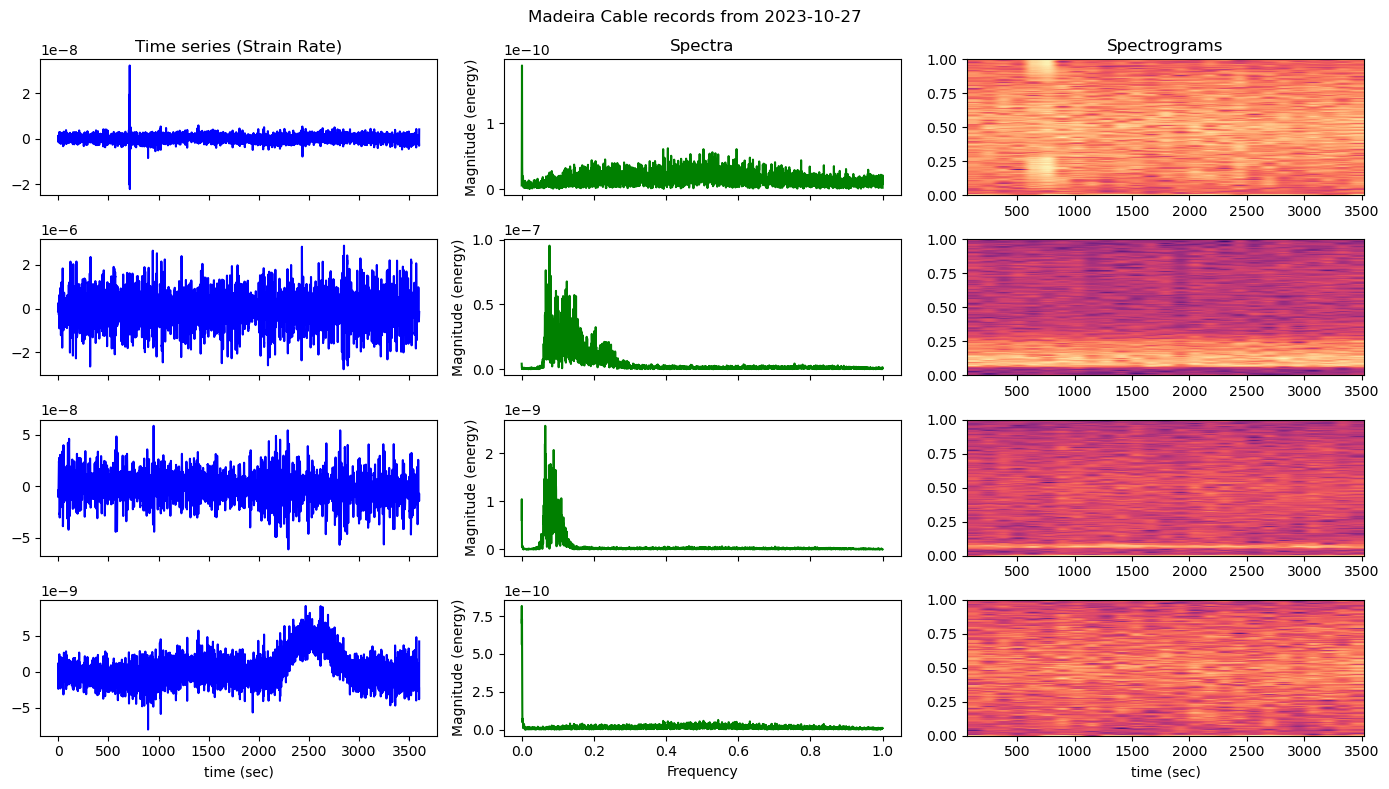

In [40]:
fig, axs = plt.subplots(4,3,figsize=(14, 8))
fig.suptitle('Madeira Cable records from 2023-10-27')

t = np.arange(0,3600,1/2) # time in seconds

# Left column plots
axs[0,0].set_title('Time series (Strain Rate)')
axs[0,0].plot(t,dset[:,15],color='blue')
axs[0,0].set_xlabel('')
axs[0,0].set_xticklabels([])
axs[1,0].plot(t,dset[:,48],color='blue')
axs[1,0].set_xlabel('')
axs[1,0].set_xticklabels([])
axs[2,0].plot(t,dset[:,80],color='blue')
axs[2,0].set_xlabel('')
axs[2,0].set_xticklabels([])
axs[3,0].plot(t,dset[:,200],color='blue')
axs[3,0].set_xlabel('time (sec)')

# Middle column plots

# plotting the magnitude spectrum of the signal 
## axs[0].magnitude_spectrum(dset[:,10], color ='green',scale='dB')
## axs[1].magnitude_spectrum(dset[:,100], color ='green',scale='dB')
axs[0,1].magnitude_spectrum(dset[:,15], color ='green')
axs[0,1].set_xlabel('')
axs[0,1].set_xticklabels([])
axs[0,1].set_title('Spectra')

axs[1,1].magnitude_spectrum(dset[:,48], color ='green')
axs[1,1].set_xlabel('')
axs[1,1].set_xticklabels([])

axs[2,1].magnitude_spectrum(dset[:,80], color ='green')
axs[2,1].set_xlabel('')
axs[2,1].set_xticklabels([])
axs[3,1].magnitude_spectrum(dset[:,200], color ='green')

# Right column plots
axs[0,2].set_title('Spectrograms')

# ROW 0: Channel 10 (Land)
# NFFT=4096 gives a frequency resolution of ~0.012 Hz
axs[0, 2].specgram(dset[:, 15], NFFT=512, Fs=2, noverlap=256, cmap='magma')
# axs[0, 2].set_title("Spectrogram: 1.0 km")

axs[1, 2].specgram(dset[:, 48], NFFT=512, Fs=2, noverlap=256, cmap='magma')

axs[2, 2].specgram(dset[:, 100], NFFT=512, Fs=2, noverlap=256, cmap='magma')

axs[3, 2].specgram(dset[:, 750], NFFT=512, Fs=2, noverlap=256, cmap='magma')
axs[3,2].set_xlabel('time (sec)')
# Right column plots
# 4. Clean up the axis if needed (as we discussed before)
axs[0, 1].set_xlabel('')      # Turn off the label
axs[0, 1].set_xticklabels([]) # Turn off the numbers

plt.tight_layout()

__Some things to try out for yourselves__ <br>
Make plots, spectra and spectrograms of other channels. What do they look like?

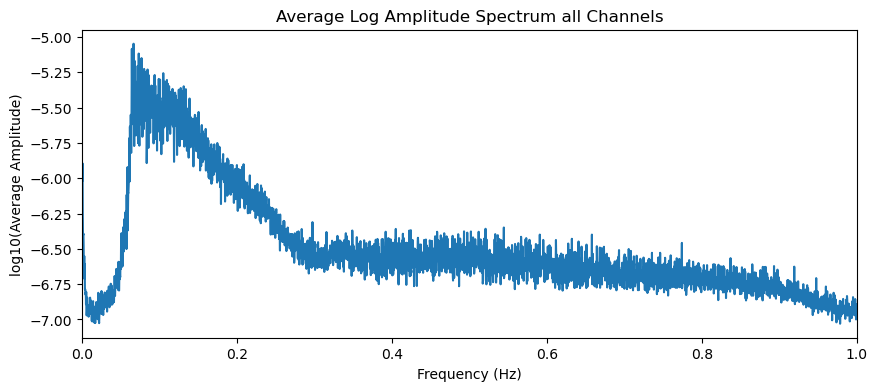

In [16]:
def average_ampspec(dataArray,fs=2.0):
    # --- ASSUMPTIONS ---
    # Assuming 'data_array' is your NumPy array (Time Samples, Channels)
    # Assuming Fs = 100.0 (Sampling Rate)
    # --------------------

    # 1. Perform 1D FFT on the time axis (axis=0) for all channels
    # The result 'fft_data' is a 2D array: (Frequency components, Channels)
    # data_array = dataArray.to_numpy()
    fft_data = np.fft.fft(dataArray, axis=0)

    # 2. Calculate the complex amplitude spectrum
    # 'amplitude_spectra' is a 2D array: (Frequency components, Channels)
    amplitude_spectra = np.abs(fft_data)

    # 3. CRUCIAL STEP: Calculate the average across the channel axis (axis=1)
    # The result 'average_spectrum' is a single 1D array of length N_time
    average_spectrum = np.mean(amplitude_spectra, axis=1)

    # 4. Prepare the Frequency axis (for plotting)
    Fs = fs
    N_time = dataArray.shape[0]
    freq = np.fft.fftfreq(N_time, 1/Fs)

    # --- Plotting the Result ---

    # We only plot the positive frequency side (up to the Nyquist frequency)
    positive_freq_slice = slice(0, N_time // 2)
    positive_freq = freq[positive_freq_slice]
    avg_amp_positive = average_spectrum[positive_freq_slice]

    # Plot the average spectrum
    fig = plt.figure(figsize=(10, 4))
    plt.plot(positive_freq, np.log10(avg_amp_positive)) # Use log scale for better visualization
    plt.title('Average Log Amplitude Spectrum all Channels')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('log10(Average Amplitude)')
    plt.xlim(0, Fs/2) # Limit to Nyquist frequency
    ## plt.savefig('merged_files/Average Amplitude Spectrum_601To1000channels.png')
    ## plt.close(fig)
    plt.show()
average_ampspec(dset)
## average_ampspec(das_data_array[601:1000])

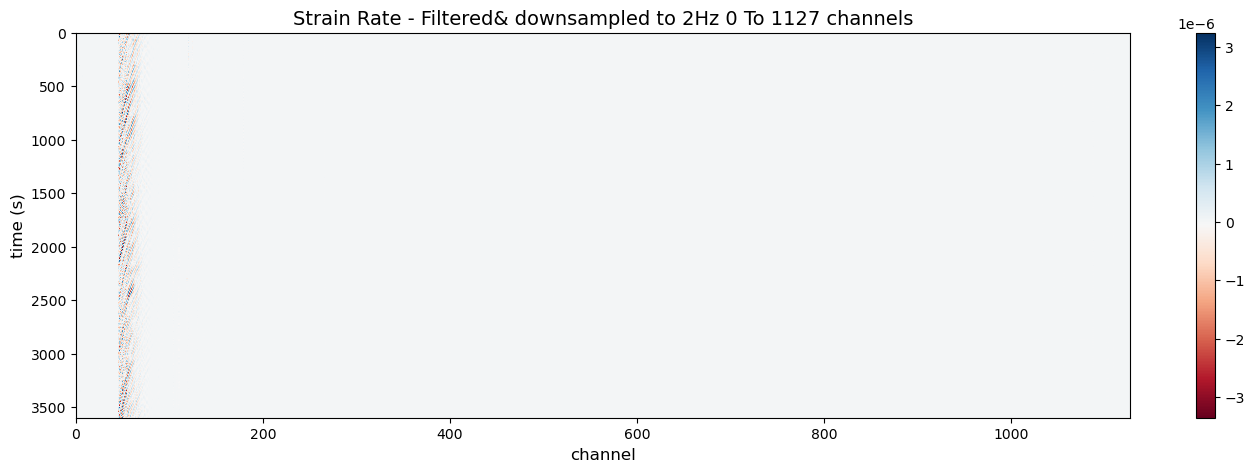

In [20]:
# modified function from original (Eileen Martin's tutorial)
def plotTimeSpace(someData, minSec, maxSec, minCh, maxCh, title, sampleRate):
    # Basic error checking
    if (minSec >= maxSec) or (minSec < 0) or (maxSec * sampleRate > someData.shape[0]):
        print("ERROR in plotSpaceTime inputs minSec: " + str(minSec) + " or maxSec: " + str(maxSec))
        return
    if (minCh >= maxCh) or (minCh < 0) or (maxCh > someData.shape[1]):
        print("Error in plotSpaceTime inputs minCh: " + str(minCh) + " or maxCh: " + str(maxCh) + " referring to array with " + str(someData.shape[1]) + " channels.")
        return

    # turn time range (in seconds) to indices
    minSecID = int(minSec * sampleRate)
    maxSecID = int(maxSec * sampleRate)

    # make the plot
    fig = plt.figure(figsize=(17,5))

    #Transpose the data for plotting time on y-axis, channels on x-axis.
    plt.imshow(someData[minCh:maxCh, minSecID:maxSecID],aspect='auto', interpolation='none', cmap='RdBu', extent=(minCh, maxCh, maxSec, minSec))

    plt.ylabel('time (s)', fontsize=12) #switched labels
    plt.xlabel('channel', fontsize=12) #switched labels
    plt.title(f"Strain Rate - {title} {minCh} To {maxCh} channels", fontsize=14)
    plt.colorbar()

    ## filename=f"TimeSpace_{title}{minCh}To{maxCh}_channels.png"
    ## save_path = os.path.join(merged_files, filename)
    ## plt.savefig(save_path)
    ## plt.close(fig)
    plt.show() #added show so the plot shows
plotTimeSpace(dset,0,3600,0,1127,'Filtered& downsampled to 2Hz',2)

In [44]:
# Also from Eileen Martin's tutorial
def plotArraySpec(dataArray, minSec, maxSec, minCh, maxCh, minFrq, maxFrq, sampleRate, title,  scale='linear'):

  # check for valid inputs (note- these checks aren't exhaustive)
  if(maxFrq <= minFrq):
    print("ERROR in plotArraySpec inputs: minFrq "+str(minFrq)+" >= maxFrq "+str(maxFrq))
    return
  if maxSec <= minSec:
    print("ERROR in plotArraySpec inputs: minSec "+str(minSec)+" >= maxSec "+str(maxSec))
    return
  if (scale != 'linear')  and (scale  != 'log10'): # only 2 scale keywords are recognized
    print("ERROR  in plotArraySpec inputs: scale keyword "+scale+" is not recognized")

  # figure out sample indices for time window of interest
  startTimeIdx =  int(minSec*sampleRate)
  endTimeIdx = int(maxSec*sampleRate)
  if endTimeIdx > dataArray.shape[0]: # another opportunity for error checking: don't request a time bigger than what's available.
    print("ERROR in plotArraySpec inputs: maxSec "+str(maxSec)+" exceeds last time in dataArray")

  # calculate the amplitude spectrum (not amplitude symmetry for +/- frequencies)
  spectrum = ft.fft(dataArray[minCh:maxCh+1,startTimeIdx:endTimeIdx+1],axis=-1) 
  nFrqBins = int(spectrum.shape[0]/2) # number of frequency bins 
  amplitudeSpec =np.absolute(spectrum[:,:nFrqBins])

  # calculate indices corresponding to the frequencies of interest
  NyquistFrq = sampleRate/2.0 # the Nyquist frequency
  # make sure maxFrq doesn't exceed Nyquist  frequency
  if(maxFrq > NyquistFrq):
    print("ERROR in plotArraySpec inputs: maxFrq "+str(maxFrq)+" >= Nyquist frequency "+str(NyquistFrq)+" indicated by sampleRate "+str(sampleRate))
    return
  # convert frequencies to an index in the array
  HzPerBin = NyquistFrq/float(nFrqBins) 
  minFrqIdx =  int(minFrq/HzPerBin) 
  maxFrqIdx =  int(maxFrq/HzPerBin)
  frqs = np.linspace(minFrqIdx*HzPerBin,maxFrqIdx*HzPerBin,num=(maxFrqIdx-minFrqIdx+1))

  # actually do the plot
  fig = plt.figure(figsize=(5,7))
  
  # for coloring extent
  log_data_slice=np.log10(amplitudeSpec[:, minFrqIdx:maxFrqIdx])
  global_min = log_data_slice.min()
  global_max = log_data_slice.max()
    
  if scale  == 'linear':
    plt.imshow(amplitudeSpec[:,minFrqIdx:maxFrqIdx],aspect='auto',interpolation='none',cmap='viridis',origin='lower',extent=(minFrq,maxFrq,maxCh,minCh)) 
  elif scale == 'log10':
    plt.imshow(np.log10(amplitudeSpec[:,minFrqIdx:maxFrqIdx]),aspect='auto',interpolation='none',cmap='grey',extent=(minFrq,maxFrq,maxCh,minCh),vmin=global_min,vmax=global_max) 
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Channel')
    # plt.colorbar('Strain Rate')
    plt.title(title)
    ## plt.savefig('LogAmplitudeSpectrum.png')
    ## plt.close(fig)
    plt.show()
# plotArraySpec(dset, minSec=0, maxSec=3600, minCh=0, maxCh=1127, minFrq=0, maxFrq=1, sampleRate=2, title='Lowpassed and downsampled to 2Hz',  scale='log10')

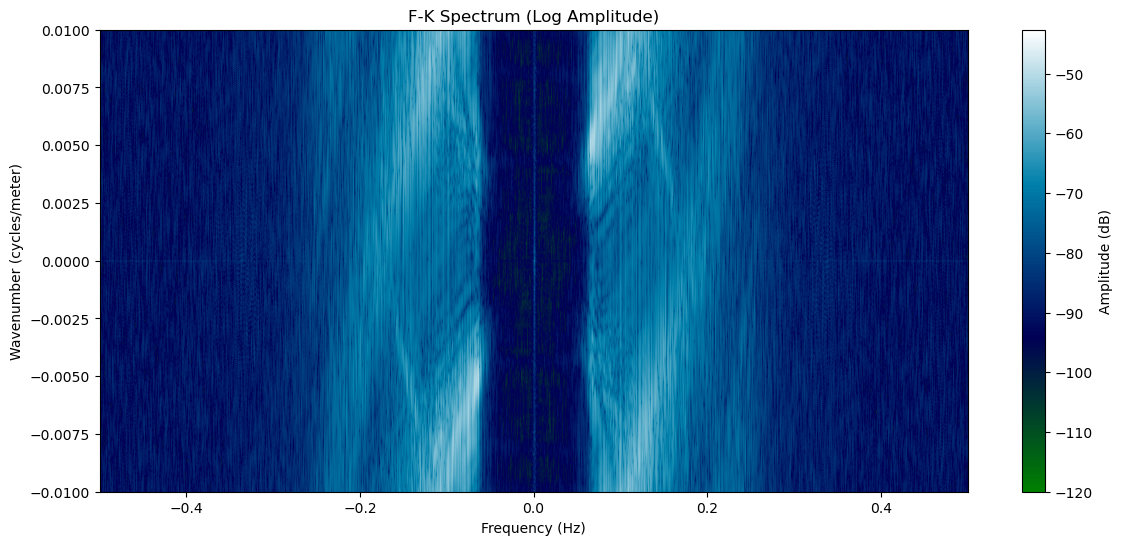

In [22]:
def fk_spectrum(dataArray, sampleRate, channelSpacing, mycmap,f_max_zoom):
    # Ensure data is (Time, Channels) for standard FFT axes
    # Transpose if necessary, but we'll assume (Time, Channel) from downsampling
    
    # 1. 2D FFT
    fk_spectrum = ft.fft2(dataArray)

    # 2. Shift Data and Calculate Log Amplitude
    # CRITICAL FIX 1: Apply fftshift to the spectrum
    fk_spectrum_shifted = ft.fftshift(fk_spectrum)
    # CRITICAL FIX 2: Use Log Amplitude for contrast
    log_amplitude_spectrum_db = 20 * np.log10(np.abs(fk_spectrum_shifted) + 1e-6)

    # 3. Frequency and Wavenumber Axes (CRITICAL FIX 3: Shift Axes)
    n_time_samples = dataArray.shape[0]
    n_channels = dataArray.shape[1]

    # Calculate and SHIFT the axes to match the center-zeroed spectrum
    frequencies = ft.fftshift(ft.fftfreq(n_time_samples, d=1 / sampleRate))
    wavenumbers = ft.fftshift(ft.fftfreq(n_channels, d=channelSpacing))

    # 4. Transpose (if needed for plotting)
    # If dataArray is (Time, Channel), fft2 returns (Freq, Wavenumber).
    # To plot with Freq on X and Wavenumber on Y, we transpose.
    # Note: If your original data was (Channel, Time), skip the transpose.
    plot_data = log_amplitude_spectrum_db.T # Assuming (Freq, Wavenumber) -> (Wavenumber, Freq) for imshow

    # 5. Plotting
    
    # Check if Freq is X-axis and Wavenumber is Y-axis in the transposed plot:
    extent = [frequencies.min(), frequencies.max(), wavenumbers.min(), wavenumbers.max()]
    
    # --- Zoom Limits ---
    # CRITICAL FIX 4: Correct Frequency Zoom (from 50 Hz Nyquist)
    # f_max_zoom = 40.0   # Zoom to ±40 Hz
    k_max_zoom = 1 / (2 * channelSpacing) # 0.05   # Zoom to ±0.05 cycles/m (to clearly see features near the center)

    fig = plt.figure(figsize=(14, 6))
    plt.imshow(plot_data, 
               aspect='auto', 
               extent=extent,
               origin='lower',
               vmin=-120,
               cmap=mycmap)

    plt.xlim(-f_max_zoom, f_max_zoom)
    plt.ylim(-k_max_zoom, k_max_zoom)
    #plt.ylim(-0.015,0.015)
# --------------------------------------------------------------------------------
    # ... Plotting lines of constant velocities of ocean and seismic waves ...
    
# -----------------------------------------------------------------------------------------------  
    plt.ylabel('Wavenumber (cycles/meter)')
    plt.xlabel('Frequency (Hz)')
    plt.colorbar(label='Amplitude (dB)')
    plt.title('F-K Spectrum (Log Amplitude)')
    plt.show()

    return fk_spectrum# End of function
fk_spectrum_all = fk_spectrum(dset, sampleRate=2, channelSpacing=50, mycmap='ocean',f_max_zoom=0.5)

### How do we identify noisy channels? <br>
One way is to calculate the STD

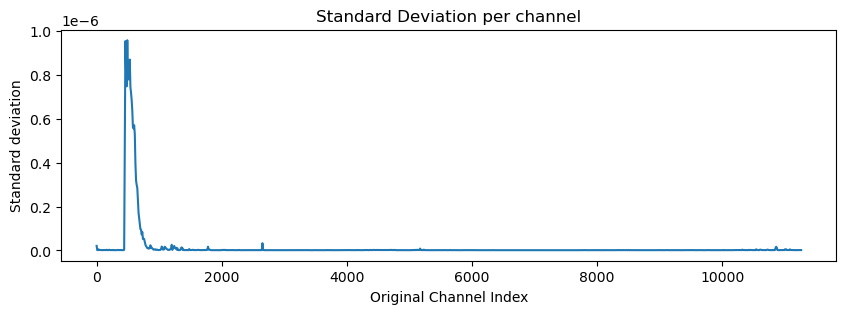

In [23]:
fig = plt.figure(figsize=(10, 3))
st_dev = np.std(dset,axis=0) # calculate STD for each channel
# Create x-axis labels to match the original channel IDs
chIndex = np.arange(0,11270,10)
plt.ylabel('Standard deviation')
plt.xlabel('Original Channel Index')
plt.title('Standard Deviation per channel')
plt.plot(chIndex,st_dev);

***
### Types of waves that occur in the ocean 
<img src="OceanWavesFigure3_1.jpg" width="500" align="center" style="margin-right: 20px;">
Figure 1: [Figure 3.1] from Folley, M. (2017). The Wave Energy Resource. In: Pecher, A., Kofoed, J. (eds) Handbook of Ocean Wave Energy. Ocean Engineering & Oceanography, vol 7. Springer, Cham. https://doi.org/10.1007/978-3-319-39889-1_3

***

__Band Name,Frequency Range (Hz),Typical Phenomena,Rationale__ <br>
* Microseismic/Tectonic,0.02−1.0,"Long-period seismic waves, deep tectonic signals, very distant earthquakes.",Isolates very low-frequency geological signals from local activity.

* Local Seismic/Traffic,1.0−10.0,"Local earthquakes, high-frequency teleseismic phases, heavy vehicle traffic, machinery.",A good band for near-field events and surface waves.

* Acoustic/Vibrations,10.0−30.0,"Foot traffic, small local impacts, high-frequency machinery noise, wind-induced vibrations.",Captures higher frequency noise/events common near the surface.

* High-Frequency Noise,30.0−50.0,"Electrical noise, instrument noise, very high-frequency environmental noise.",Can be used to monitor the instrument's noise floor and cable self-noise.

__Band Name,Frequency Range (Hz),Physical Source,Oceanographic/Seismic Phenomena__ <br>

* Ocean-Induced Strain,0.005−0.05,"Slow fluctuations, pressure changes","Ocean Tides, Static Strain, very-long-period acoustic modes. (You rejected below 0.02 Hz due to noise, but this is the band for ultra-low signals.)"

* Ocean Swell / Microseisms,0.05−0.5,"Surface gravity waves, wind-wave interactions","Ocean Swell/Waves, Primary and Secondary Microseisms (ambient seismic noise created by waves)."

* Marine Life / Acoustic,1.0−50.0,Biological and Anthropogenic sources,"Whale Vocalizations (often <100 Hz), Ship Noise (propeller cavitation, engine noise), passing boats."

* Seismic/Earthquakes,0.5−20.0,Geological processes,"Earthquakes (local and distant), Fault Activity, seafloor landslides.

***

Define a function which will plot timeseries from the different channels in the file

In [24]:
# modified function from original (Eileen Martin's tutorial)
def plotSpaceTime(someData, minSec, maxSec, minCh, maxCh, title, sampleRate):
    # Basic error checking
    if (minSec >= maxSec) or (minSec < 0) or (maxSec * sampleRate > someData.shape[0]):
        print("ERROR in plotSpaceTime inputs minSec: " + str(minSec) + " or maxSec: " + str(maxSec))
        return
    if (minCh >= maxCh) or (minCh < 0) or (maxCh > someData.shape[1]):
        print("Error in plotSpaceTime inputs minCh: " + str(minCh) + " or maxCh: " + str(maxCh) + " referring to array with " + str(someData.shape[1]) + " channels.")
        return

    # turn time range (in seconds) to indices
    minSecID = int(minSec * sampleRate)
    maxSecID = int(maxSec * sampleRate)

    # make the plot
    fig = plt.figure(figsize=(17,5))

    #Transpose the data for plotting time on y-axis, channels on x-axis.
    plt.imshow(someData[minSecID:maxSecID,minCh:maxCh], aspect='auto', interpolation='none', cmap='seismic', extent=(minSec, maxSec, maxCh, minCh))

    plt.ylabel('time (s)', fontsize=12) #switched labels
    plt.xlabel('channel', fontsize=12) #switched labels
    plt.title(f"Strain Rate - {title} {minCh} To {maxCh} channels", fontsize=14)
    plt.colorbar()
    ### plt.savefig(f"SpaceTime_{title}{minCh}To{maxCh}_channels.png")
    ### plt.close(fig)
    plt.show() #added show so the plot shows.

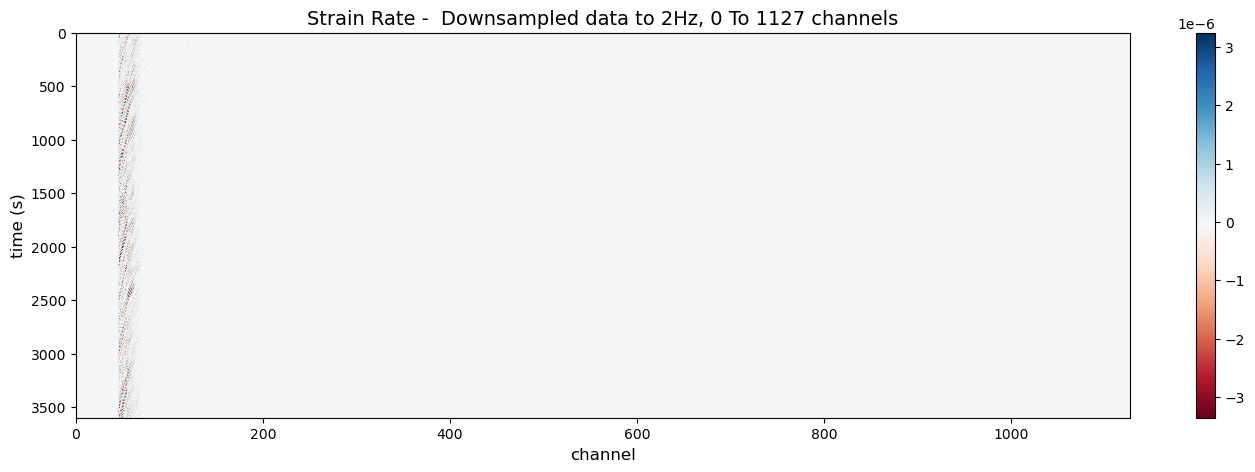

In [26]:
minSec = 0
maxSec = 3600
minCh = 0
maxCh = 1127
title = ' Downsampled data to 2Hz,'
sampleRate = 2
# plotSpaceTime(data_2hz, minSec, maxSec, minCh, maxCh, title, sampleRate)
plotTimeSpace(dset, minSec, maxSec, minCh, maxCh, title, sampleRate)

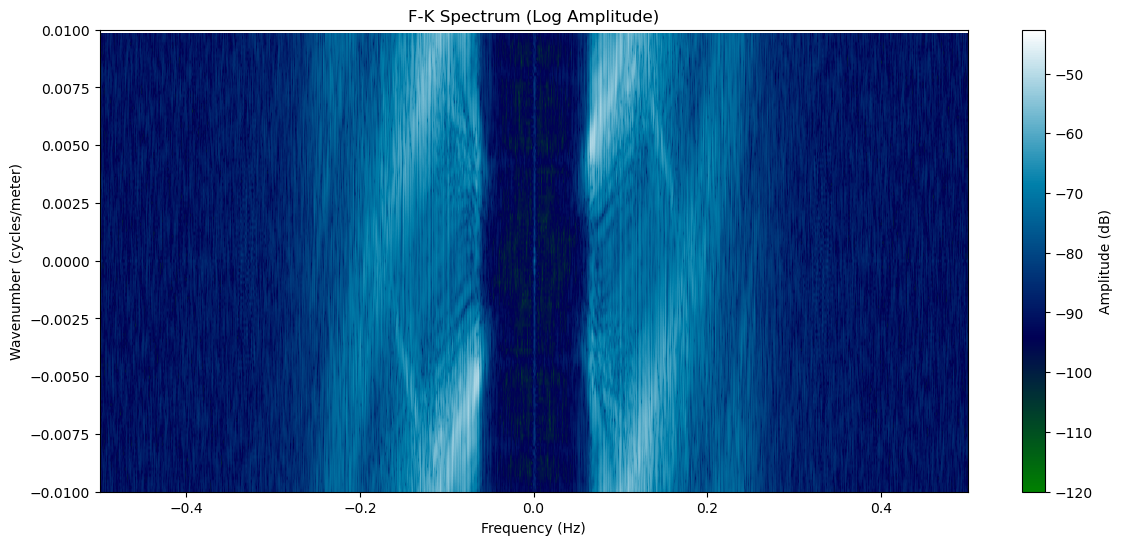

In [28]:
channels_0To150 = dset[:,0:150]
fk_spectrum0To150 = fk_spectrum(channels_0To150, sampleRate=2, channelSpacing=50, mycmap='ocean',f_max_zoom=0.5)

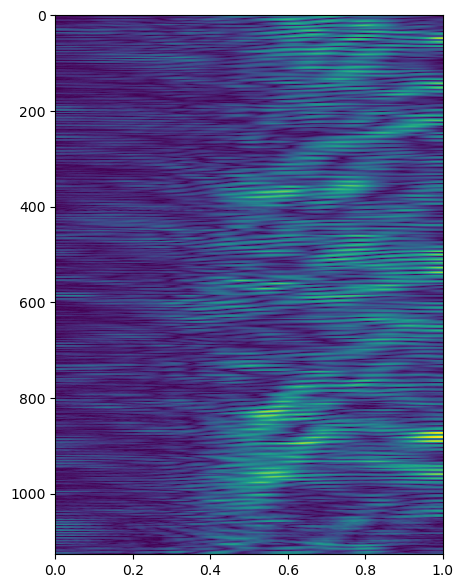

In [29]:
plotArraySpec(dset, minSec=0, maxSec=3600, minCh=0, maxCh=1127, minFrq=0, maxFrq=1, sampleRate=2, title='Lowpassed and downsampled to 2Hz',  scale='linear')

In [32]:
def AmplitudeSpectrum(sr,n,timesignal):
    """
    Calculates Amplitude Spectrum of a single time series
    as included in a column in a pandas dataframe

    Parameters needed for this function are:
    1. sr: sampling rate
    2. : number of samples
    3. time series in numpy array format

    The function produces a spectrum plot in loglog scale 
    """
    # Initialise variables
    fs= sr                     # Hz  sample rate
    N = n # Number of sample points
    T = N/fs #time in seconds

    # Calculate the full (double-sided) frequency vector
    freq = np.fft.fftfreq(N, d=1/fs)

    # Determine the index for the Nyquist frequency (half the data)
    M = N // 2

    x =  timesignal         # time signal (i.e. final_SR_numpy[:,0])
    X = fft(x)

    # --- 2. Calculate and Plot the Fourier Amplitude Spectrum ---

    # Extract the single-sided data and apply amplitude scaling
    # Multiply by 2/N to get the true single-sided amplitude (excluding DC and Nyquist)
    # Note: We use slicing to get the first M points (0 to Nyquist)
    X_amplitude = np.abs(X[:M]) * (2 / N) 


    # The frequency axis only needs the positive frequencies
    freq_positive = freq[:M]

    fig = plt.figure()
    #plt.plot(freq_positive, X_amplitude, 'b')
    plt.loglog(freq_positive, X_amplitude, 'b')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude (Scaled $|X(f)|$)')
    plt.title('Fourier Amplitude Spectrum')
    # plt.xlim(0, fs/2) # Limits to 0-250 Hz (Nyquist)
    plt.grid(True)
    plt.show()
    ### plt.savefig(f'AmplitudeSpectrum_channel1500.png')
    ### plt.close(fig)
# Sample use
# AmplitudeSpectrum(2,7200,dset[:,100])